In [1]:
'''
See how the autaptic RS neuron compares to the IB neuron firing dynamics...

'''

from aqua.AQUA_general import AQUA
from aqua.batchAQUA_general import *
from aqua.plotting_functions import *
from aqua.stimulus import step_current, filtered_white_noise_fast
from aqua.utils import STA

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from brian2 import *
from tqdm import tqdm   # for a progress bar
import seaborn as sns
sns.set_theme(style = "white")

# local imports
import CLI
import CF
from functions import *

In [ ]:
# pyramidal cells: L2/3/5/6
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}    # Class 1

# pyramidal cells: all layers, abundantly L5
IB = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0., 'f': 0., 'tau': 0.}

In [3]:
T = 2    # ms
dt = 0.1    # ms
N_iter = int(1000.*T/dt)

RS_neuron = AQUA(RS)
IB_neuron = AQUA(IB)

# initialise
x_start = np.array([-60, 0, 0])
t_start = np.array([0.])
RS_neuron.Initialise(x_start, t_start)
IB_neuron.Initialise(x_start, t_start)

# injected current just above threshold for RS bursting
I_RS = 70 * np.ones(N_iter)
I_IB = 700 * np.ones(N_iter)

# simulate
X_RS, T, spikes_RS = RS_neuron.update_RK2(dt, N_iter, I_RS)
X_IB, T, spikes_IB = IB_neuron.update_RK2(dt, N_iter, I_IB)

100%|██████████| 19999/19999 [00:00<00:00, 86408.47it/s]


Text(85.0, 0.5, 'injected current (IB) [pA]')

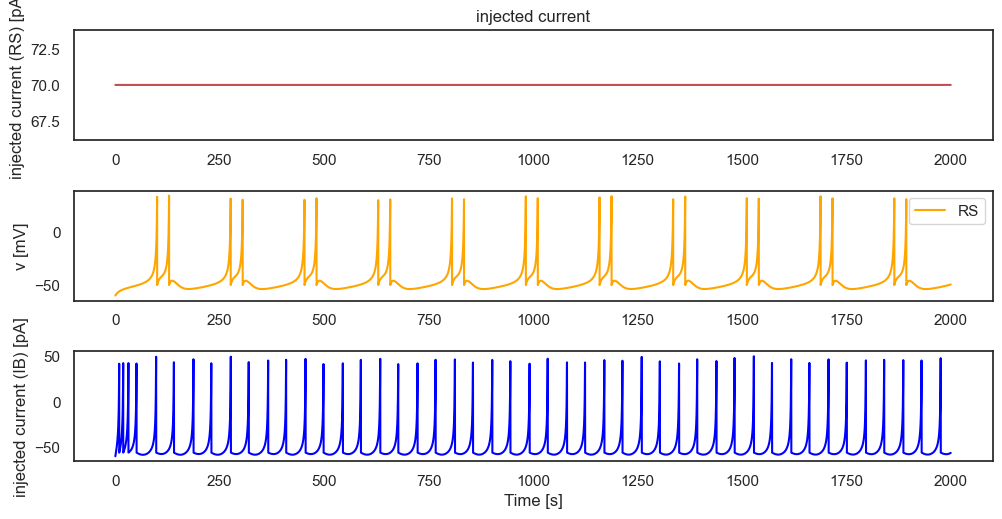

In [4]:
fig, ax = plt.subplots(3, 1, figsize = (10, 5))
fig.tight_layout()

ax[0].plot(T, I_RS, c = 'r')
ax[0].title.set_text('injected current')
ax[0].set_ylabel('injected current (RS) [pA]')

ax[1].plot(T, X_RS[0, :], c = 'orange', label = 'RS')
#ax[1].plot(T, X_IB[0, :], c = 'blue', label = 'IB')
ax[1].set_ylabel('v [mV]')
ax[1].legend()

ax[2].plot(T, X_IB[0, :], c = 'blue', label = 'IB')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('injected current (IB) [pA]')

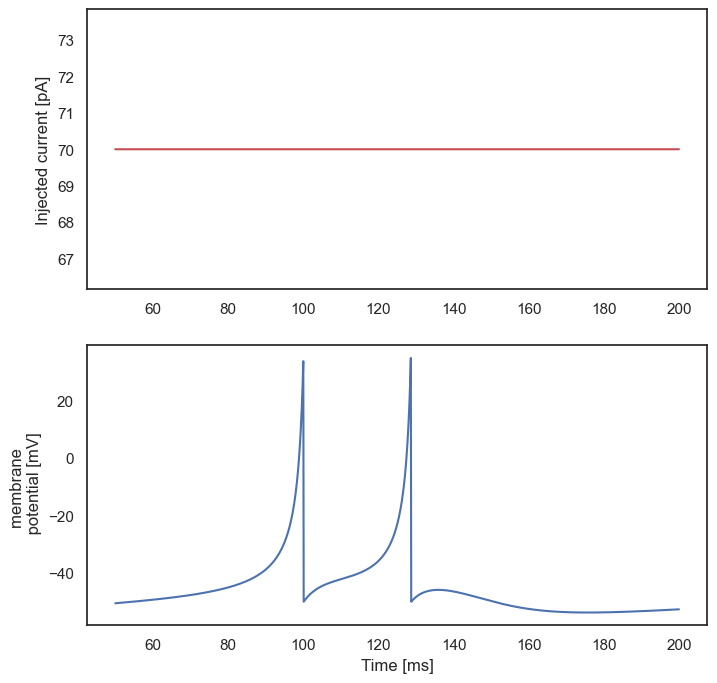

In [5]:
split = range(500, 2000)
fig, ax = plot_potential_versus_injected(X_RS, T, I_RS, split = split)

plt.show()